In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ----------------------------------------------------------------
# 1. CONFIG
# ----------------------------------------------------------------

import kagglehub
DATASET_PATH = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")          # Change to your dataset path
BATCH_SIZE   = 32
NUM_EPOCHS   = 10
LR           = 0.001
NUM_CLASSES  = 4
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES  = ["glioma", "meningioma", "notumor", "pituitary"]

print(f"Using device: {DEVICE}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Using device: cuda


In [ ]:
# ----------------------------------------------------------------
# 2. DATA TRANSFORMS (No enhancement — just resize + normalize)
# ----------------------------------------------------------------

from torchvision import transforms

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),       # basic augmentation
        transforms.RandomRotation(10),           # basic augmentation
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],          # ImageNet mean
            std=[0.229, 0.224, 0.225]            # ImageNet std
        )
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
}

In [ ]:
# ----------------------------------------------------------------
# 3. DATASET LOADER
# ----------------------------------------------------------------
def load_data(dataset_path, transforms_dict):
    train_path = os.path.join(dataset_path, "Training")
    test_path  = os.path.join(dataset_path, "Testing")

    train_dataset = ImageFolder(root=train_path, transform=transforms_dict["train"])
    test_dataset  = ImageFolder(root=test_path,  transform=transforms_dict["test"])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Train samples : {len(train_dataset)}")
    print(f"Test  samples : {len(test_dataset)}")
    print(f"Classes       : {train_dataset.classes}")

    return train_loader, test_loader

In [ ]:
# ----------------------------------------------------------------
# 4. MODEL BUILDER
# ----------------------------------------------------------------
def build_model(model_name, num_classes, freeze_backbone=True):
    """
    model_name: 'resnet50' or 'mobilenet'
    freeze_backbone: freeze pretrained layers, only train classifier
    """
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        # Replace final FC layer
        in_features = model.fc.in_features          # 2048
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name == "mobilenet":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        # Replace final classifier
        in_features = model.classifier[1].in_features  # 1280
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)

In [ ]:
NUM_EPOCHS = 10

# ----------------------------------------------------------------
# 5. TRAINING LOOP
# ----------------------------------------------------------------
def train_model(model, train_loader, test_loader, model_name, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc       = 0.0

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    print(f"\n{'='*50}")
    print(f"Training: {model_name.upper()}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        start = time.time()

        # ---- Train Phase ----
        model.train()
        running_loss    = 0.0
        running_correct = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss    += loss.item() * images.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_loss = running_loss    / len(train_loader.dataset)
        epoch_acc  = running_correct / len(train_loader.dataset)

        # ---- Eval Phase ----
        test_acc = evaluate(model, test_loader)

        scheduler.step()

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc       = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Loss: {epoch_loss:.4f} | "
              f"Train Acc: {epoch_acc*100:.2f}% | "
              f"Test Acc: {test_acc*100:.2f}% | "
              f"Time: {elapsed:.1f}s")

    print(f"\nBest Test Accuracy ({model_name}): {best_acc*100:.2f}%")

    model.load_state_dict(best_model_wts)
    return model, history, best_acc

In [ ]:
# ----------------------------------------------------------------
# 6. EVALUATION
# ----------------------------------------------------------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs        = model(images)
            correct       += (outputs.argmax(1) == labels).sum().item()
    return correct / len(loader.dataset)


def full_evaluation(model, loader, model_name, class_names=CLASS_NAMES):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,       # ← fixed
                yticklabels=class_names)       # ← fixed
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name}.png")
    plt.show()

    print(f"\nClassification Report — {model_name}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
# ----------------------------------------------------------------
# 7. PLOT TRAINING HISTORY
# ----------------------------------------------------------------
def plot_history(histories):
    """Plot accuracy curves for all models"""
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    for name, h in histories.items():
        plt.plot(h["train_loss"], label=f"{name}")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for name, h in histories.items():
        plt.plot(h["test_acc"], label=f"{name}")
    plt.title("Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig("training_history.png")
    plt.show()
    print("Saved: training_history.png")

Train samples : 5600
Test  samples : 1600
Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]



Training: RESNET50_NORMAL
Epoch [01/10] Loss: 0.6350 | Train Acc: 74.64% | Test Acc: 72.69% | Time: 57.8s
Epoch [02/10] Loss: 0.4620 | Train Acc: 82.52% | Test Acc: 82.19% | Time: 45.5s
Epoch [03/10] Loss: 0.4306 | Train Acc: 84.32% | Test Acc: 83.44% | Time: 39.6s
Epoch [04/10] Loss: 0.4022 | Train Acc: 84.61% | Test Acc: 77.81% | Time: 39.7s
Epoch [05/10] Loss: 0.3988 | Train Acc: 84.71% | Test Acc: 79.06% | Time: 40.4s
Epoch [06/10] Loss: 0.3385 | Train Acc: 87.46% | Test Acc: 82.88% | Time: 39.3s
Epoch [07/10] Loss: 0.3194 | Train Acc: 88.07% | Test Acc: 82.25% | Time: 39.3s
Epoch [08/10] Loss: 0.3114 | Train Acc: 88.73% | Test Acc: 83.81% | Time: 39.7s
Epoch [09/10] Loss: 0.3090 | Train Acc: 88.61% | Test Acc: 83.81% | Time: 39.5s
Epoch [10/10] Loss: 0.3100 | Train Acc: 88.30% | Test Acc: 84.62% | Time: 39.2s

Best Test Accuracy (ResNet50_Normal): 84.62%


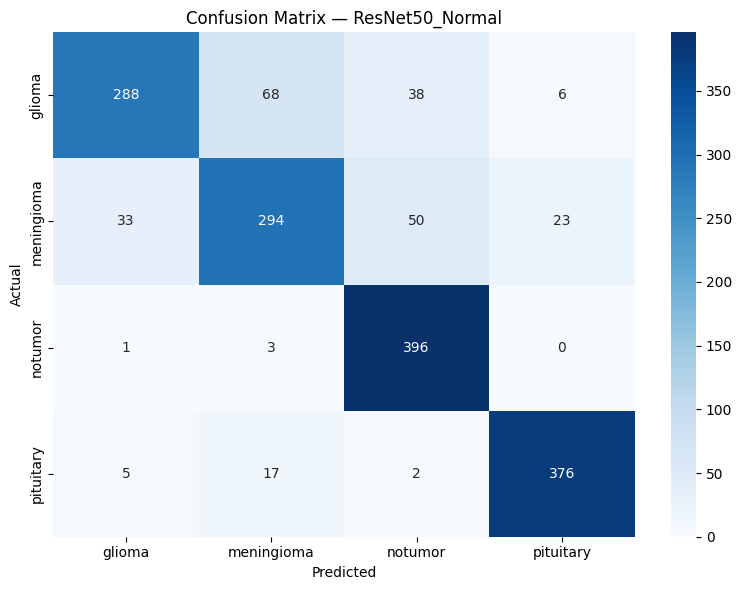


Classification Report — ResNet50_Normal
              precision    recall  f1-score   support

      glioma       0.88      0.72      0.79       400
  meningioma       0.77      0.73      0.75       400
     notumor       0.81      0.99      0.89       400
   pituitary       0.93      0.94      0.93       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


Training: MOBILENET_NORMAL


Epoch [01/10] Loss: 0.5967 | Train Acc: 78.29% | Test Acc: 80.94% | Time: 34.0s
Epoch [02/10] Loss: 0.4276 | Train Acc: 84.18% | Test Acc: 82.06% | Time: 33.6s
Epoch [03/10] Loss: 0.3916 | Train Acc: 85.52% | Test Acc: 82.75% | Time: 33.7s
Epoch [04/10] Loss: 0.3654 | Train Acc: 86.29% | Test Acc: 83.25% | Time: 34.3s
Epoch [05/10] Loss: 0.3566 | Train Acc: 86.48% | Test Acc: 82.94% | Time: 33.6s
Epoch [06/10] Loss: 0.3214 | Train Acc: 88.12% | Test Acc: 83.81% | Time: 33.8s
Epoch [07/10] Loss: 0.3218 | Train Acc: 87.88% | Test Acc: 83.56% | Time: 34.4s
Epoch [08/10] Loss: 0.3315 | Train Acc: 87.30% | Test Acc: 83.81% | Time: 33.4s
Epoch [09/10] Loss: 0.3201 | Train Acc: 88.39% | Test Acc: 84.00% | Time: 34.1s
Epoch [10/10] Loss: 0.3255 | Train Acc: 88.04% | Test Acc: 84.19% | Time: 34.3s

Best Test Accuracy (MobileNet_Normal): 84.19%


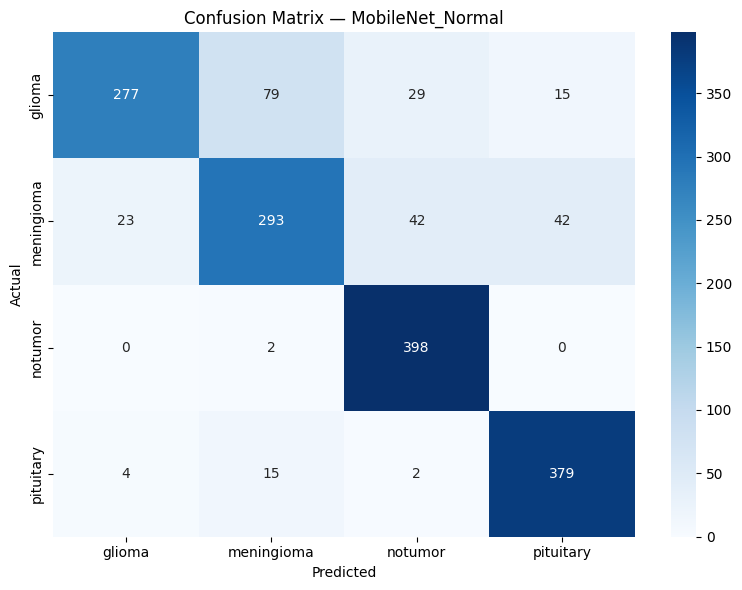


Classification Report — MobileNet_Normal
              precision    recall  f1-score   support

      glioma       0.91      0.69      0.79       400
  meningioma       0.75      0.73      0.74       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.87      0.95      0.91       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



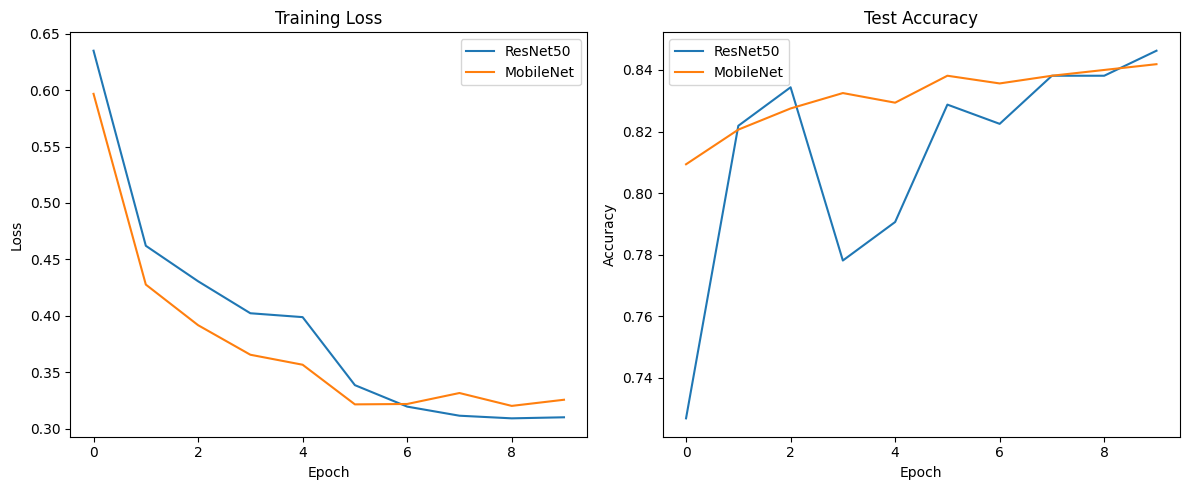

Saved: training_history.png


In [ ]:
# ----------------------------------------------------------------
# 9. MAIN
# ----------------------------------------------------------------

DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"
BATCH_SIZE = 32
NUM_CLASSES = 4
LR = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import os
import torch
import time
import torch.nn as nn
import copy
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# REPLACE WITH:
# Load data
train_loader, test_loader = load_data(DATASET_PATH, data_transforms)

results   = {}
histories = {}

resnet_model = build_model("resnet50", NUM_CLASSES, freeze_backbone=True)
resnet_model, resnet_history, resnet_acc = train_model(
    resnet_model, train_loader, test_loader,
    model_name="ResNet50_Normal"
)
full_evaluation(resnet_model, test_loader, "ResNet50_Normal")
torch.save(resnet_model.state_dict(), "resnet50_normal.pth")

results["ResNet50"]   = (resnet_acc, "Normal")
histories["ResNet50"] = resnet_history

mobile_model = build_model("mobilenet", NUM_CLASSES, freeze_backbone=True)
mobile_model, mobile_history, mobile_acc = train_model(
    mobile_model, train_loader, test_loader,
    model_name="MobileNet_Normal"
)
full_evaluation(mobile_model, test_loader, "MobileNet_Normal")
torch.save(mobile_model.state_dict(), "mobilenet_normal.pth")

results["MobileNet"]   = (mobile_acc, "Normal")
histories["MobileNet"] = mobile_history

plot_history(histories)

In [ ]:
print("\n" + "="*55)
print(f"{'Model':<20} {'Data':<15} {'Accuracy':>12}")
print("="*55)
print(f"{'ResNet50':<20} {'Normal':<15} {resnet_acc*100:>11.2f}%")
print(f"{'MobileNet':<20} {'Normal':<15} {mobile_acc*100:>11.2f}%")
print("="*55)


Model                Data                Accuracy
ResNet50             Normal                84.62%
MobileNet            Normal                84.19%


In [ ]:
# CELL 1 — Channel Attention Module
# ================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        # Shared MLP — same weights used for both avg and max pool
        self.shared_mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # Global Average Pool → (B, C)
        avg = F.adaptive_avg_pool2d(x, 1).view(B, C)
        # Global Max Pool → (B, C)
        mx  = F.adaptive_max_pool2d(x, 1).view(B, C)

        # Pass both through SAME MLP
        avg_out = self.shared_mlp(avg)   # (B, C)
        max_out = self.shared_mlp(mx)    # (B, C)

        # Add, sigmoid, reshape to (B, C, 1, 1)
        scale = torch.sigmoid(avg_out + max_out).view(B, C, 1, 1)

        # Scale input channels
        return x * scale

print("✅ ChannelAttention defined")

✅ ChannelAttention defined


In [ ]:
# CELL 2 — Spatial Attention Module
# ================================================================
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        # Single conv: 2 channels (avg+max) → 1 attention map
        self.conv = nn.Conv2d(
            in_channels  = 2,
            out_channels = 1,
            kernel_size  = kernel_size,
            padding      = kernel_size // 2,
            bias         = False
        )

    def forward(self, x):
        # Average across channels → (B, 1, H, W)
        avg = torch.mean(x, dim=1, keepdim=True)
        # Max across channels → (B, 1, H, W)
        mx, _ = torch.max(x, dim=1, keepdim=True)

        # Stack along channel dim → (B, 2, H, W)
        combined = torch.cat([avg, mx], dim=1)

        # Conv + sigmoid → spatial attention map (B, 1, H, W)
        scale = torch.sigmoid(self.conv(combined))

        # Scale each spatial location
        return x * scale

print("✅ SpatialAttention defined")

✅ SpatialAttention defined


In [ ]:
# CELL 3 — Full CBAM Module
# ================================================================
class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        # Step 1: WHAT features matter (channel)
        x = self.channel_attention(x)
        # Step 2: WHERE to focus (spatial)
        x = self.spatial_attention(x)
        return x

print("✅ CBAM defined")

✅ CBAM defined


In [ ]:
# CELL 4 — ResNet50 + CBAM Builder
# ================================================================
import torchvision.models as models

def build_resnet50_cbam(num_classes=4):

    # Load pretrained ResNet50
    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V1
    )

    # ── Insert CBAM after each ResNet layer block ──
    # ResNet50 layer output channels:
    # layer1 → 256 channels
    # layer2 → 512 channels
    # layer3 → 1024 channels
    # layer4 → 2048 channels

    model.layer1 = nn.Sequential(model.layer1, CBAM(256))
    model.layer2 = nn.Sequential(model.layer2, CBAM(512))
    model.layer3 = nn.Sequential(model.layer3, CBAM(1024))
    model.layer4 = nn.Sequential(model.layer4, CBAM(2048))

    # ── Freeze pretrained layers, keep CBAM + FC trainable ──
    for name, param in model.named_parameters():
        is_cbam = any(k in name for k in [
            "channel_attention",
            "spatial_attention",
            "fc"
        ])
        param.requires_grad = is_cbam

    # ── Custom classifier head ──
    model.fc = nn.Sequential(
        nn.Linear(2048, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    # Print trainable vs frozen
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params : {trainable:,}")
    print(f"Frozen params    : {total - trainable:,}")
    print(f"Total params     : {total:,}")

    return model.to(DEVICE)

print("✅ build_resnet50_cbam() defined")

✅ build_resnet50_cbam() defined


Trainable params : 1,747,852
Frozen params    : 23,508,032
Total params     : 25,255,884

Training: RESNET50_CBAM_NORMAL
Epoch [01/10] Loss: 0.5281 | Train Acc: 79.20% | Test Acc: 76.25% | Time: 51.7s
Epoch [02/10] Loss: 0.3206 | Train Acc: 88.16% | Test Acc: 85.50% | Time: 50.5s
Epoch [03/10] Loss: 0.2580 | Train Acc: 90.71% | Test Acc: 87.19% | Time: 50.7s
Epoch [04/10] Loss: 0.2304 | Train Acc: 91.93% | Test Acc: 88.56% | Time: 50.6s
Epoch [05/10] Loss: 0.2017 | Train Acc: 92.79% | Test Acc: 87.69% | Time: 50.6s
Epoch [06/10] Loss: 0.1536 | Train Acc: 94.34% | Test Acc: 90.69% | Time: 50.1s
Epoch [07/10] Loss: 0.1355 | Train Acc: 95.23% | Test Acc: 91.19% | Time: 50.3s
Epoch [08/10] Loss: 0.1285 | Train Acc: 95.50% | Test Acc: 91.44% | Time: 49.9s
Epoch [09/10] Loss: 0.1270 | Train Acc: 95.27% | Test Acc: 91.88% | Time: 50.1s
Epoch [10/10] Loss: 0.1263 | Train Acc: 95.21% | Test Acc: 92.06% | Time: 50.6s

Best Test Accuracy (ResNet50_CBAM_Normal): 92.06%


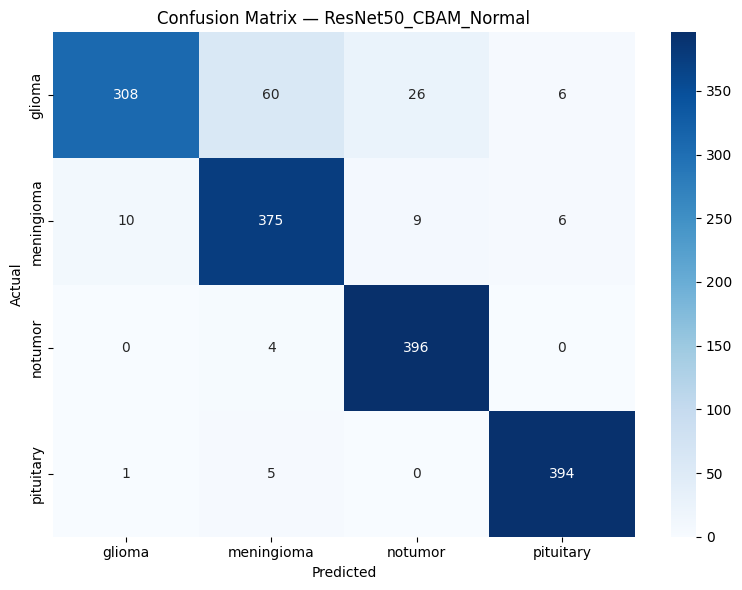


Classification Report — ResNet50_CBAM_Normal
              precision    recall  f1-score   support

      glioma       0.97      0.77      0.86       400
  meningioma       0.84      0.94      0.89       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600

✅ ResNet50+CBAM saved | Accuracy: 92.06%


In [ ]:
# CELL 5 — Train ResNet50 + CBAM
# ================================================================

NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cbam_model = build_resnet50_cbam(num_classes=NUM_CLASSES)

cbam_model, cbam_history, cbam_acc = train_model(
    cbam_model,
    train_loader,
    test_loader,
    model_name="ResNet50_CBAM_Normal"
)

full_evaluation(cbam_model, test_loader, "ResNet50_CBAM_Normal")
torch.save(cbam_model.state_dict(), "resnet50_cbam_normal.pth")
print(f"✅ ResNet50+CBAM saved | Accuracy: {cbam_acc*100:.2f}%")

In [ ]:
# CELL 6 — Updated Comparison Table
# ================================================================
print("\n" + "="*65)
print(f"{'Model':<25} {'Attention':<12} {'Data':<12} {'Accuracy':>10}")
print("="*65)
print(f"{'ResNet50':<25} {'None':<12} {'Normal':<12} {resnet_acc*100:>9.2f}%")
print(f"{'MobileNet':<25} {'None':<12} {'Normal':<12} {mobile_acc*100:>9.2f}%")
print(f"{'ResNet50 + CBAM':<25} {'CBAM':<12} {'Normal':<12} {cbam_acc*100:>9.2f}%")
print("="*65)

improvement = cbam_acc - resnet_acc
print(f"\nCBAM Improvement over ResNet50 baseline: {improvement*100:+.2f}%")


Model                     Attention    Data           Accuracy
ResNet50                  None         Normal           84.62%
MobileNet                 None         Normal           84.19%
ResNet50 + CBAM           CBAM         Normal           92.06%

CBAM Improvement over ResNet50 baseline: +7.44%


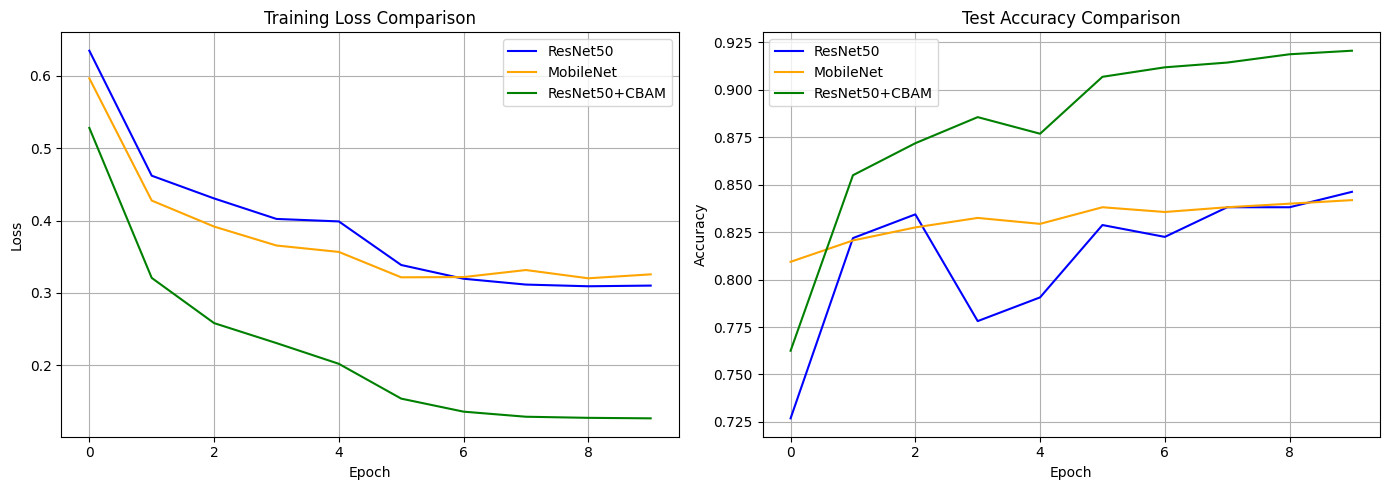

✅ Saved: comparison_curves.png


In [ ]:
# CELL 7 — Training Curves (All 3 Models)
# ================================================================
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(resnet_history["train_loss"], label="ResNet50",      color="blue")
plt.plot(mobile_history["train_loss"], label="MobileNet",     color="orange")
plt.plot(cbam_history["train_loss"],   label="ResNet50+CBAM", color="green")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(resnet_history["test_acc"], label="ResNet50",      color="blue")
plt.plot(mobile_history["test_acc"], label="MobileNet",     color="orange")
plt.plot(cbam_history["test_acc"],   label="ResNet50+CBAM", color="green")
plt.title("Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("comparison_curves.png")
plt.show()
print("✅ Saved: comparison_curves.png")

In [ ]:
# CELL 1 — Enhancement Functions
# ================================================================
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

def enhance_mri(image):
    """
    Input  : PIL Image (RGB)
    Output : PIL Image (RGB) enhanced

    Steps:
    1. Convert RGB → Grayscale (MRI is grayscale anyway)
    2. Gaussian blur → remove noise
    3. CLAHE → enhance local contrast
    4. Convert back to RGB (model expects 3 channels)
    """
    # Step 1 — PIL to numpy
    img_np = np.array(image)

    # Step 2 — Convert to grayscale
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Step 3 — Gaussian blur (noise removal)
    denoised = cv2.GaussianBlur(gray, (5, 5), 0)

    # Step 4 — CLAHE (contrast enhancement)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    # Step 5 — Back to 3 channel RGB
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    # Step 6 — Back to PIL
    return Image.fromarray(enhanced_rgb)


print("✅ enhance_mri() defined")

✅ enhance_mri() defined


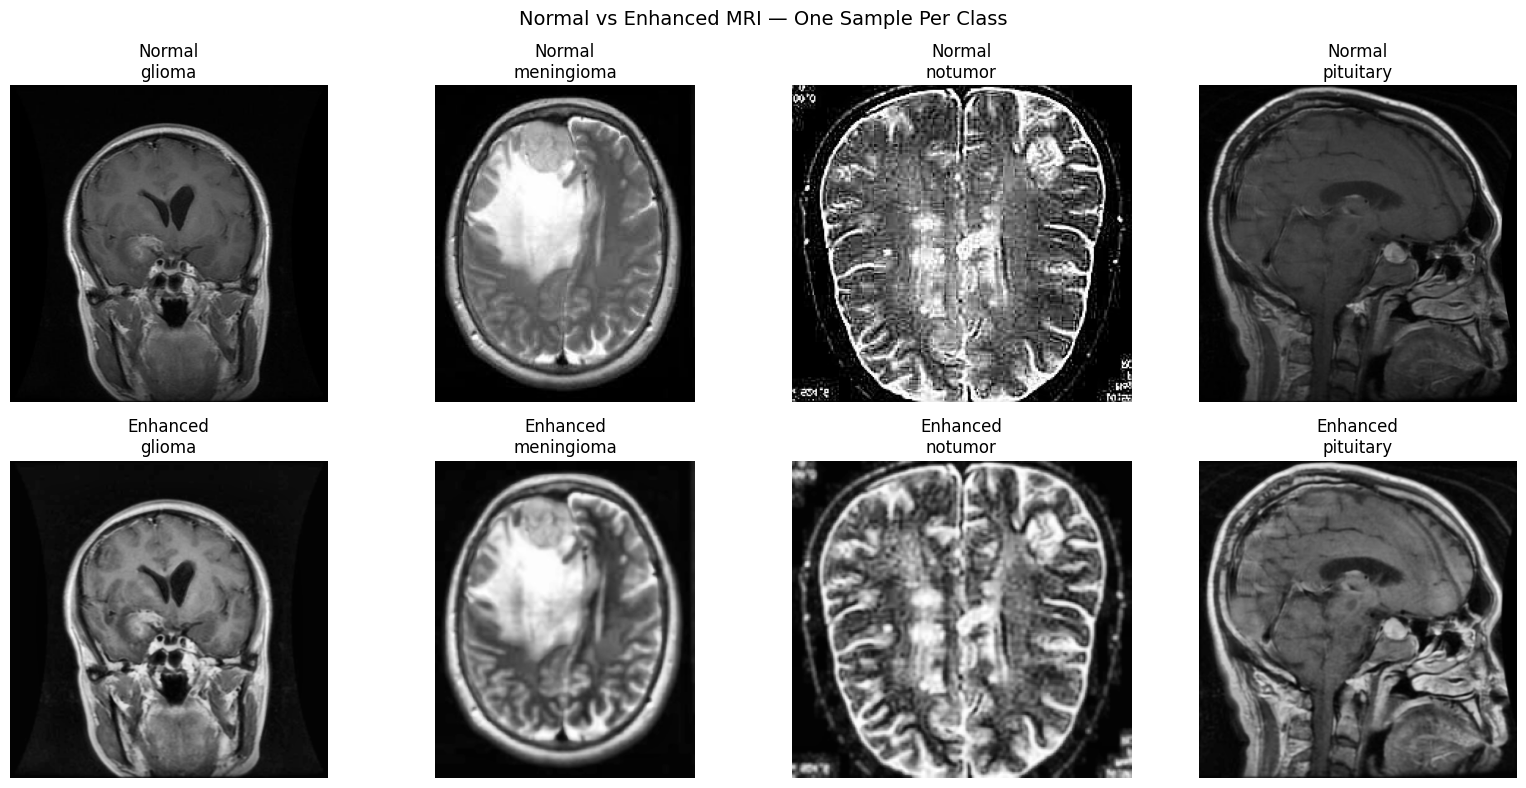

✅ Saved: normal_vs_enhanced.png


In [ ]:
# CELL 2 — Visualize Normal vs Enhanced (sanity check)
# ================================================================
import matplotlib.pyplot as plt
import os

# Pick one sample image from each class
sample_images = {}
test_root = os.path.join(DATASET_PATH, "Testing")

for class_name in CLASS_NAMES:
    class_folder = os.path.join(test_root, class_name)
    first_image  = os.listdir(class_folder)[0]
    img_path     = os.path.join(class_folder, first_image)
    sample_images[class_name] = Image.open(img_path).convert("RGB")

# Plot Normal vs Enhanced side by side for each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Normal vs Enhanced MRI — One Sample Per Class", fontsize=14)

for i, (class_name, img) in enumerate(sample_images.items()):
    enhanced = enhance_mri(img)

    # Row 0 — Normal
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Normal\n{class_name}")
    axes[0, i].axis("off")

    # Row 1 — Enhanced
    axes[1, i].imshow(enhanced)
    axes[1, i].set_title(f"Enhanced\n{class_name}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("normal_vs_enhanced.png")
plt.show()
print("✅ Saved: normal_vs_enhanced.png")

In [ ]:
# CELL 3 — Enhanced Transforms
# ================================================================

# Custom transform that applies enhancement FIRST
# then standard preprocessing
class EnhancedTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, image):
        # Apply MRI enhancement
        image = enhance_mri(image)
        # Then apply standard transforms
        return self.base_transform(image)


# Base transforms (same as before)
base_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

base_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Enhanced versions
enhanced_train_transform = EnhancedTransform(base_train_transform)
enhanced_test_transform  = EnhancedTransform(base_test_transform)

print("✅ Enhanced transforms ready")

✅ Enhanced transforms ready


In [ ]:
# CELL 4 — Enhanced DataLoaders
# ================================================================

enh_train_dataset = ImageFolder(
    root      = os.path.join(DATASET_PATH, "Training"),
    transform = enhanced_train_transform
)
enh_test_dataset  = ImageFolder(
    root      = os.path.join(DATASET_PATH, "Testing"),
    transform = enhanced_test_transform
)

enh_train_loader = DataLoader(
    enh_train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2
)
enh_test_loader  = DataLoader(
    enh_test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2
)

print(f"✅ Enhanced train samples : {len(enh_train_dataset)}")
print(f"✅ Enhanced test  samples : {len(enh_test_dataset)}")

✅ Enhanced train samples : 5600
✅ Enhanced test  samples : 1600



Training: RESNET50_ENHANCED
Epoch [01/10] Loss: 0.6678 | Train Acc: 73.91% | Test Acc: 71.94% | Time: 60.9s
Epoch [02/10] Loss: 0.5013 | Train Acc: 81.34% | Test Acc: 81.12% | Time: 55.7s
Epoch [03/10] Loss: 0.4227 | Train Acc: 84.20% | Test Acc: 80.62% | Time: 57.2s
Epoch [04/10] Loss: 0.4215 | Train Acc: 84.29% | Test Acc: 79.88% | Time: 58.1s
Epoch [05/10] Loss: 0.4163 | Train Acc: 84.38% | Test Acc: 82.50% | Time: 56.9s
Epoch [06/10] Loss: 0.3427 | Train Acc: 87.20% | Test Acc: 82.12% | Time: 58.2s
Epoch [07/10] Loss: 0.3223 | Train Acc: 87.89% | Test Acc: 82.88% | Time: 56.1s
Epoch [08/10] Loss: 0.3201 | Train Acc: 87.95% | Test Acc: 83.00% | Time: 56.8s
Epoch [09/10] Loss: 0.3147 | Train Acc: 88.32% | Test Acc: 82.62% | Time: 55.7s
Epoch [10/10] Loss: 0.3048 | Train Acc: 88.70% | Test Acc: 83.31% | Time: 55.7s

Best Test Accuracy (ResNet50_Enhanced): 83.31%


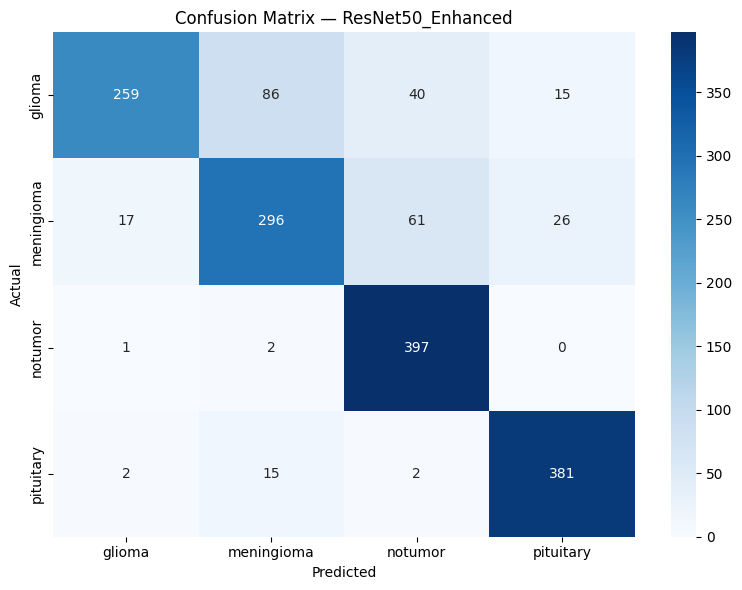


Classification Report — ResNet50_Enhanced
              precision    recall  f1-score   support

      glioma       0.93      0.65      0.76       400
  meningioma       0.74      0.74      0.74       400
     notumor       0.79      0.99      0.88       400
   pituitary       0.90      0.95      0.93       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600

✅ ResNet50+Enhanced saved | Accuracy: 83.31%


In [ ]:
# CELL 5 — Train ResNet50 + Enhanced Images
# ================================================================
resnet_enh_model = build_model("resnet50", NUM_CLASSES)

resnet_enh_model, resnet_enh_history, resnet_enh_acc = train_model(
    resnet_enh_model,
    enh_train_loader,
    enh_test_loader,
    model_name="ResNet50_Enhanced"
)

full_evaluation(resnet_enh_model, enh_test_loader, "ResNet50_Enhanced")
torch.save(resnet_enh_model.state_dict(), "resnet50_enhanced.pth")
print(f"✅ ResNet50+Enhanced saved | Accuracy: {resnet_enh_acc*100:.2f}%")

Trainable params : 1,747,852
Frozen params    : 23,508,032
Total params     : 25,255,884

Training: RESNET50_CBAM_ENHANCED
Epoch [01/10] Loss: 0.5323 | Train Acc: 79.57% | Test Acc: 82.56% | Time: 65.0s
Epoch [02/10] Loss: 0.3262 | Train Acc: 88.27% | Test Acc: 83.81% | Time: 64.9s
Epoch [03/10] Loss: 0.2950 | Train Acc: 89.27% | Test Acc: 84.56% | Time: 64.7s
Epoch [04/10] Loss: 0.2616 | Train Acc: 90.20% | Test Acc: 87.69% | Time: 64.8s
Epoch [05/10] Loss: 0.2311 | Train Acc: 91.52% | Test Acc: 88.88% | Time: 64.8s
Epoch [06/10] Loss: 0.1740 | Train Acc: 93.36% | Test Acc: 88.75% | Time: 65.1s
Epoch [07/10] Loss: 0.1652 | Train Acc: 93.89% | Test Acc: 89.69% | Time: 65.2s
Epoch [08/10] Loss: 0.1612 | Train Acc: 94.04% | Test Acc: 89.81% | Time: 64.9s
Epoch [09/10] Loss: 0.1587 | Train Acc: 94.09% | Test Acc: 90.06% | Time: 64.3s
Epoch [10/10] Loss: 0.1528 | Train Acc: 94.32% | Test Acc: 90.69% | Time: 64.1s

Best Test Accuracy (ResNet50_CBAM_Enhanced): 90.69%


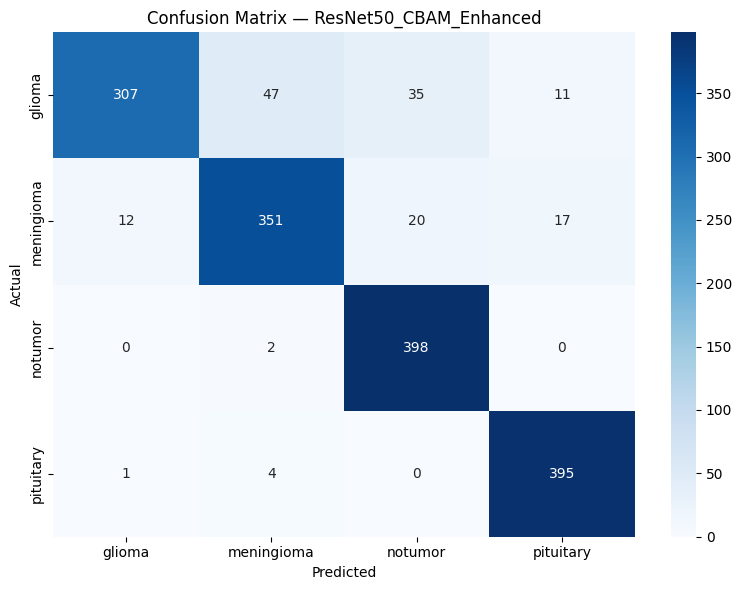


Classification Report — ResNet50_CBAM_Enhanced
              precision    recall  f1-score   support

      glioma       0.96      0.77      0.85       400
  meningioma       0.87      0.88      0.87       400
     notumor       0.88      0.99      0.93       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600

✅ ResNet50+CBAM+Enhanced saved | Accuracy: 90.69%


In [ ]:
# CELL 6 — Train ResNet50 + CBAM + Enhanced Images
# ================================================================
cbam_enh_model = build_resnet50_cbam(num_classes=NUM_CLASSES)

cbam_enh_model, cbam_enh_history, cbam_enh_acc = train_model(
    cbam_enh_model,
    enh_train_loader,
    enh_test_loader,
    model_name="ResNet50_CBAM_Enhanced"
)

full_evaluation(cbam_enh_model, enh_test_loader, "ResNet50_CBAM_Enhanced")
torch.save(cbam_enh_model.state_dict(), "resnet50_cbam_enhanced.pth")
print(f"✅ ResNet50+CBAM+Enhanced saved | Accuracy: {cbam_enh_acc*100:.2f}%")


Training: MOBILENET_ENHANCED
Epoch [01/10] Loss: 0.6122 | Train Acc: 77.61% | Test Acc: 78.44% | Time: 50.0s
Epoch [02/10] Loss: 0.4213 | Train Acc: 84.91% | Test Acc: 79.62% | Time: 50.2s
Epoch [03/10] Loss: 0.3752 | Train Acc: 86.75% | Test Acc: 80.31% | Time: 50.0s
Epoch [04/10] Loss: 0.3695 | Train Acc: 86.61% | Test Acc: 81.94% | Time: 50.7s
Epoch [05/10] Loss: 0.3703 | Train Acc: 85.98% | Test Acc: 83.25% | Time: 50.9s
Epoch [06/10] Loss: 0.3221 | Train Acc: 88.39% | Test Acc: 82.88% | Time: 51.1s
Epoch [07/10] Loss: 0.3305 | Train Acc: 87.62% | Test Acc: 82.62% | Time: 51.0s
Epoch [08/10] Loss: 0.3272 | Train Acc: 88.29% | Test Acc: 82.25% | Time: 51.3s
Epoch [09/10] Loss: 0.3283 | Train Acc: 88.20% | Test Acc: 82.62% | Time: 51.1s
Epoch [10/10] Loss: 0.3178 | Train Acc: 88.14% | Test Acc: 82.75% | Time: 51.0s

Best Test Accuracy (MobileNet_Enhanced): 83.25%


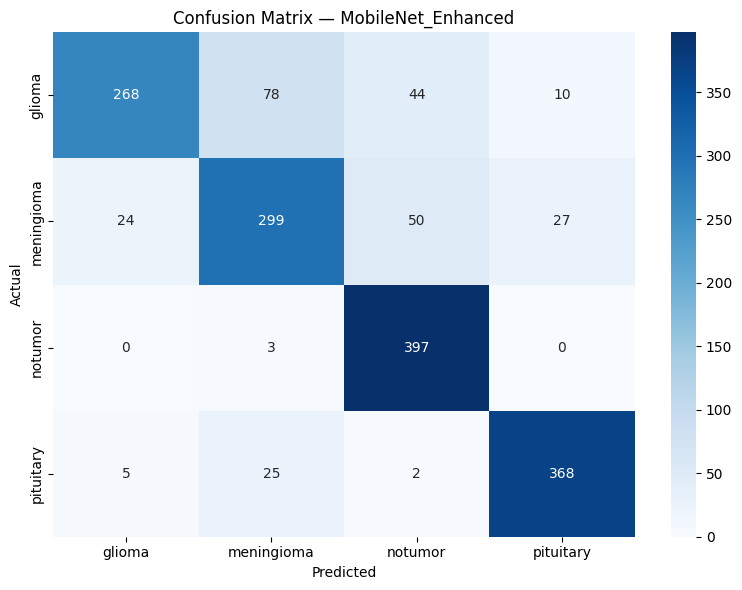


Classification Report — MobileNet_Enhanced
              precision    recall  f1-score   support

      glioma       0.90      0.67      0.77       400
  meningioma       0.74      0.75      0.74       400
     notumor       0.81      0.99      0.89       400
   pituitary       0.91      0.92      0.91       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600

✅ MobileNet+Enhanced saved | Accuracy: 83.25%


In [ ]:
# CELL 7 — Train MobileNet + Enhanced Images
# ================================================================
mobile_enh_model = build_model("mobilenet", NUM_CLASSES)

mobile_enh_model, mobile_enh_history, mobile_enh_acc = train_model(
    mobile_enh_model,
    enh_train_loader,
    enh_test_loader,
    model_name="MobileNet_Enhanced"
)

full_evaluation(mobile_enh_model, enh_test_loader, "MobileNet_Enhanced")
torch.save(mobile_enh_model.state_dict(), "mobilenet_enhanced.pth")
print(f"✅ MobileNet+Enhanced saved | Accuracy: {mobile_enh_acc*100:.2f}%")

In [ ]:
# CELL 8 — Final Comparison Table (All Experiments)
# ================================================================
print("\n" + "="*75)
print(f"{'Model':<25} {'CBAM':<8} {'Data':<12} {'Accuracy':>10} {'Improvement':>12}")
print("="*75)

experiments = [
    ("ResNet50",              "❌", "Normal",   resnet_acc),
    ("ResNet50",              "❌", "Enhanced", resnet_enh_acc),
    ("ResNet50 + CBAM",       "✅", "Normal",   cbam_acc),
    ("ResNet50 + CBAM",       "✅", "Enhanced", cbam_enh_acc),
    ("MobileNet",             "❌", "Normal",   mobile_acc),
    ("MobileNet",             "❌", "Enhanced", mobile_enh_acc),
]

baseline = resnet_acc
for model_name, cbam_flag, data_type, acc in experiments:
    diff = acc - baseline
    sign = f"+{diff*100:.2f}%" if diff >= 0 else f"{diff*100:.2f}%"
    print(f"{model_name:<25} {cbam_flag:<8} {data_type:<12} "
          f"{acc*100:>9.2f}% {sign:>12}")

print("="*75)
print(f"\nBaseline (ResNet50 Normal): {resnet_acc*100:.2f}%")
print(f"Best model: ResNet50+CBAM+Enhanced: {cbam_enh_acc*100:.2f}%")


Model                     CBAM     Data           Accuracy  Improvement
ResNet50                  ❌        Normal           84.62%       +0.00%
ResNet50                  ❌        Enhanced         83.31%       -1.31%
ResNet50 + CBAM           ✅        Normal           92.06%       +7.44%
ResNet50 + CBAM           ✅        Enhanced         90.69%       +6.06%
MobileNet                 ❌        Normal           84.19%       -0.44%
MobileNet                 ❌        Enhanced         83.25%       -1.37%

Baseline (ResNet50 Normal): 84.62%
Best model: ResNet50+CBAM+Enhanced: 90.69%


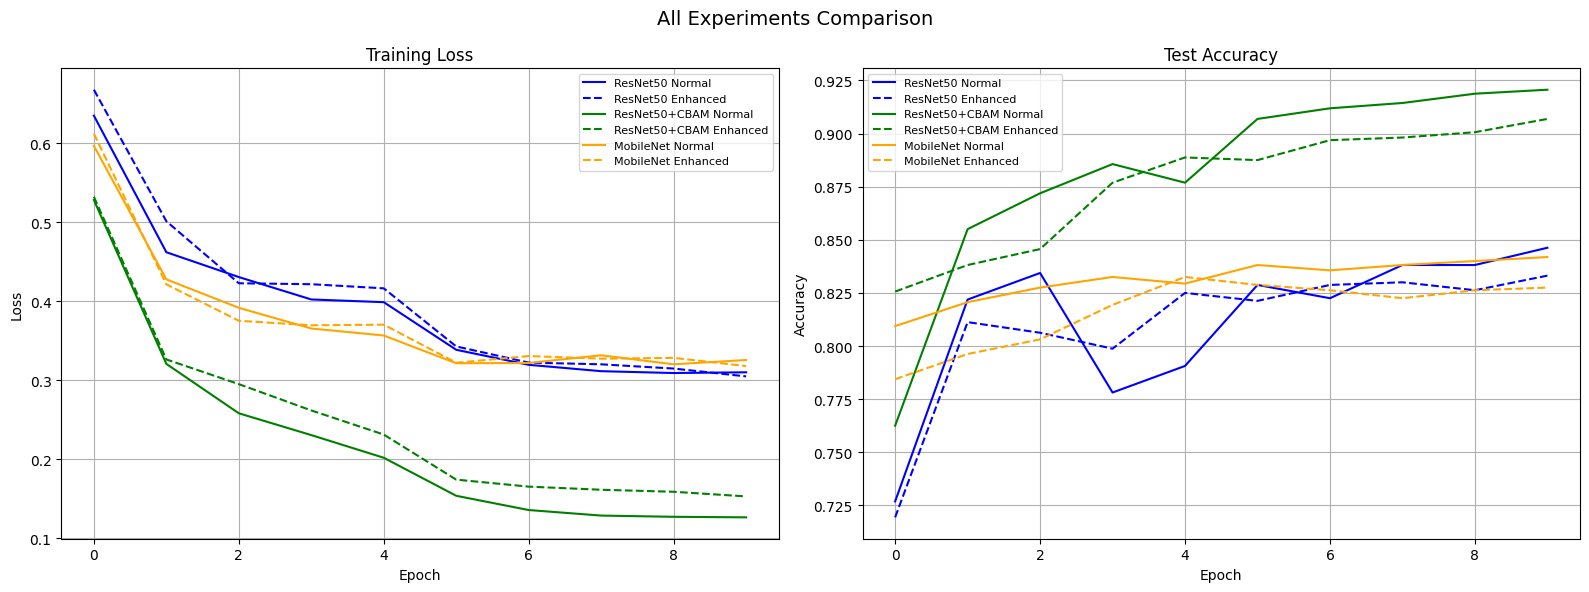

✅ Saved: all_experiments.png


In [ ]:
# CELL 9 — Full Training Curves (All Models)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    "ResNet50 Normal"        : ("blue",   "solid"),
    "ResNet50 Enhanced"      : ("blue",   "dashed"),
    "ResNet50+CBAM Normal"   : ("green",  "solid"),
    "ResNet50+CBAM Enhanced" : ("green",  "dashed"),
    "MobileNet Normal"       : ("orange", "solid"),
    "MobileNet Enhanced"     : ("orange", "dashed"),
}

all_histories = {
    "ResNet50 Normal"        : resnet_history,
    "ResNet50 Enhanced"      : resnet_enh_history,
    "ResNet50+CBAM Normal"   : cbam_history,
    "ResNet50+CBAM Enhanced" : cbam_enh_history,
    "MobileNet Normal"       : mobile_history,
    "MobileNet Enhanced"     : mobile_enh_history,
}

# Loss plot
for name, h in all_histories.items():
    color, style = colors[name]
    axes[0].plot(h["train_loss"], label=name,
                 color=color, linestyle=style)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Accuracy plot
for name, h in all_histories.items():
    color, style = colors[name]
    axes[1].plot(h["test_acc"], label=name,
                 color=color, linestyle=style)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle("All Experiments Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("all_experiments.png")
plt.show()
print("✅ Saved: all_experiments.png")